# **CDS Project: Part 1**

*Institute of Software Security (E22)*  
*Hamburg University of Technology*  
*SoSe 2023*

## Learning objectives
---

- Use a basic Machine Learning (ML) pipeline with pre-trained models.
- Build your own data loader.
- Load and run a pre-trained ML model.
- Evaluate the performance of an ML model.
- Calculate and interpret performance metrics.

## Materials
---

- Lecture Slides 1, 2, and 3.
- PyTorch Documentation: [Datasets and Data Loaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) 


## Project Description
---

In this project, you are given an ML model that is pre-trained on a vulnerability dataset. The dataset consists of code samples labeled with True or False flags, depending on the presence and absense of a vulnerability. Your goal is to use the pre-trained model to predict if the code samples in the validation set contain vulnerabilities or not and analyse the results. Please proceed to the below tasks. 

###*Task 1*

Build a data loader for the validation dataset present in the following path: "*data_students/student_dataset.hdf5*". You will be using this dataset to validate the performance of the ML model. The dataset is in HDF5 binary data format. This format is used to store large amount of data. Make sure that you import and familiarise yourself with the right Python libraries to handle HDF5 files. 


In [21]:
# Task 1 – Build a data loader for the validation dataset

# --- necessary imports ---
import h5py
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# --- path to the HDF5 dataset ---
DATA_PATH = "data_students/student_dataset.hdf5"

# --- custom PyTorch Dataset ---
class VulnDataset(Dataset):
    """
    Loads the HDF5 vulnerability dataset.
    Keys in the file:
      'vectors' – float32 embeddings, shape (N, 1, 768)
      'labels'  – bool labels,         shape (N,)
      'source'  – original code source, shape (N,)
    """
    def __init__(self, hdf5_path):
        with h5py.File(hdf5_path, 'r') as f:
            # Load everything into memory as numpy arrays
            self.vectors = np.array(f['vectors'], dtype=np.float32)   # (N, 1, 768)
            self.labels  = np.array(f['labels'],  dtype=np.float32)   # (N,)
            # source strings are stored as variable-length bytes – decode them
            self.sources = np.array(
                [s.decode('utf-8') if isinstance(s, bytes) else s for s in f['source'][:]],
                dtype=object
            )  # (N,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        vector = torch.tensor(self.vectors[idx].squeeze(0))  # shape (768,)
        label  = torch.tensor(self.labels[idx])              # scalar
        return vector, label

# --- instantiate dataset and DataLoader ---
dataset    = VulnDataset(DATA_PATH)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

print(f"Dataset loaded successfully.")
print(f"  Total samples            : {len(dataset)}")
print(f"  Vector shape             : {dataset.vectors.shape}")
print(f"  Labels shape             : {dataset.labels.shape}")
print(f"  Number of batches (bs=32): {len(dataloader)}")


Dataset loaded successfully.
  Total samples            : 1000
  Vector shape             : (1000, 1, 768)
  Labels shape             : (1000,)
  Number of batches (bs=32): 32


###*Task 2*

Generate a table with 10 random samples from the dataset and show their corresponding labels.

In [22]:
# Task 2 – Display 10 random samples from the dataset with their labels

import random

# Pick 10 random indices
random.seed(42)
sample_indices = random.sample(range(len(dataset)), 10)

# Build a DataFrame: show index, a snippet of the source code, and the label
rows = []
for idx in sample_indices:
    rows.append({
        "Sample Index": idx,
        "Label (Vulnerable)": bool(dataset.labels[idx]),
        "Source Snippet (first 120 chars)": dataset.sources[idx][:120].replace("\n", " "),
    })

df_samples = pd.DataFrame(rows)

# Display the table
pd.set_option("display.max_colwidth", 130)
display(df_samples)


,Sample Index,Label (Vulnerable),Source Snippet (first 120 chars)
0,654,False,add_notebook(const Notebook::Ptr & notebook) { if(m_notebookMap.find(notebook->get_normalized_name()) != m_not
1,114,True,"attr_add_valuearray(Slapi_Attr *a, Slapi_Value **vals, const char *dn) { int i = 0; int numofvals = 0; int d"
2,25,False,"grasp (const Event& e, Tool31& tool) { if (window_cursor == nil) { window_cursor = e.window()->cursor();"
3,759,True,"dump_s3_data(struct srec_data *srec, const char *fname) { \tFILE *f; \tint i; \tf = fopen(fname, ""w""); \tif (f == NULL) \t\tr"
4,281,False,"acc_get_first (krb5_context context, \t krb5_ccache id, \t krb5_cc_cursor *cursor) { cc_credentials_iterat"
5,250,False,tegra_max98090_probe(struct platform_device *pdev) { \tstruct device_node *np = pdev->dev.of_node; \tstruct snd_soc_card *
6,228,False,"pve_line_copy_to_exact_solution (const PVEnv *const pve, const PVCell **const line,"
7,142,True,"work_manager(dwarf *dwarf) { if(world[dwarf->pos] > (fort->dwarf_size + fort->sub_size)) { fprintf(stderr, ""A dwar"
8,754,False,GetGraphic () { Graphic* graphic = GraphicView::GetGraphic(); if (graphic == nil) { RasterRect* rr
9,104,False,"ClearCycles () { \tstd::list<Bond*>::iterator n, end = m_Bonds.end (); \tfor (n = m_Bonds.begin (); n != end; n++) \t\t(*n)-"


###*Task 3*

Inspect the dataset and answer the following questions:
1.  How many samples are in the dataset?
2. How many positive examples (vulnerability-labeled instances) are in the dataset?
3. What is the vulnerable/non-vulnerable ratio?

1. Total samples in the dataset  : 1000
2. Positive (vulnerable) examples: 283
   Negative (non-vulnerable)      : 717
3. Vulnerable / Non-vulnerable ratio: 0.3947  (283:717)


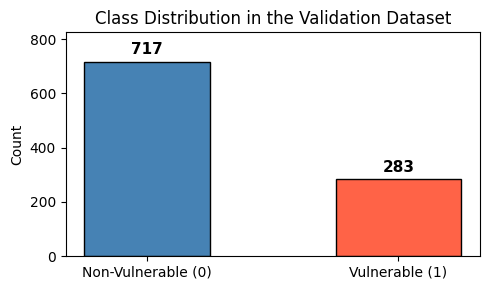

In [23]:
# Task 3 – Inspect the dataset and answer the three questions

# 1. Total number of samples
total_samples = len(dataset)

# 2. Positive examples (label == True, i.e. vulnerable)
num_vulnerable     = int(dataset.labels.sum())
num_non_vulnerable = total_samples - num_vulnerable

# 3. Vulnerable / Non-vulnerable ratio
ratio = num_vulnerable / num_non_vulnerable

print(f"1. Total samples in the dataset  : {total_samples}")
print(f"2. Positive (vulnerable) examples: {num_vulnerable}")
print(f"   Negative (non-vulnerable)      : {num_non_vulnerable}")
print(f"3. Vulnerable / Non-vulnerable ratio: {ratio:.4f}  ({num_vulnerable}:{num_non_vulnerable})")

# Visual breakdown using a bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(["Non-Vulnerable (0)", "Vulnerable (1)"],
              [num_non_vulnerable, num_vulnerable],
              color=["steelblue", "tomato"], edgecolor="black", width=0.5)
ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
ax.set_ylabel("Count")
ax.set_title("Class Distribution in the Validation Dataset")
ax.set_ylim(0, max(num_non_vulnerable, num_vulnerable) * 1.15)
plt.tight_layout()
plt.show()


###*Task 4*

Load and run the following pre-trained neural network model called VulnPredictionModel. 

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [25]:
# Task 4 – Define, initialize and load the pre-trained VulnPredictModel

import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

class VulnPredictModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_stack = nn.Sequential(
            nn.Linear(768, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
                                    # ← forward is at CLASS level, not inside __init__
    def forward(self, x):           # ← 4 spaces indent (class method)
        pred = self.linear_stack(x)
        return pred

MODEL_PATH = "model_2023-03-28_20-03.pth"
model = VulnPredictModel()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print(f"Model loaded from '{MODEL_PATH}'")
print(model)


Using cpu device
Model loaded from 'model_2023-03-28_20-03.pth'
VulnPredictModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_stack): Sequential(
    (0): Linear(in_features=768, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


###*Task 5*

Make a prediction on the provided dataset and compute the following values:
- True Positives
- True Negatives
- False Positives
- False Negatives

In [26]:
# Task 5 – Run predictions on the full dataset and compute TP, TN, FP, FN

all_preds  = []
all_labels = []

with torch.no_grad():  # no gradient needed for inference
    for vectors, labels in dataloader:
        vectors = vectors.to(device)
        outputs = model(vectors)           # shape: (batch, 1) — sigmoid probabilities
        preds   = (outputs >= 0.5).float() # threshold at 0.5 → binary prediction
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

# Flatten into 1-D tensors
all_preds  = torch.cat(all_preds).squeeze()   # shape: (1000,)
all_labels = torch.cat(all_labels).squeeze()  # shape: (1000,)

# Compute TP, TN, FP, FN
TP = int(((all_preds == 1) & (all_labels == 1)).sum())
TN = int(((all_preds == 0) & (all_labels == 0)).sum())
FP = int(((all_preds == 1) & (all_labels == 0)).sum())
FN = int(((all_preds == 0) & (all_labels == 1)).sum())

print(f"True  Positives (TP): {TP}")
print(f"True  Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"\nSanity check — total: {TP + TN + FP + FN} (should be {len(dataset)})")


True  Positives (TP): 20
True  Negatives (TN): 716
False Positives (FP): 1
False Negatives (FN): 263

Sanity check — total: 1000 (should be 1000)


### *Task 6*

Compute the corresponding performance metrics **manually** (do not use PyTorch's predefined metrics):
- Accuracy
- Precision
- Recall
- F1

In [27]:
# Task 6 – Compute performance metrics manually (no PyTorch/sklearn metrics)

# --- Accuracy ---
# (Correct predictions) / (Total predictions)
accuracy = (TP + TN) / (TP + TN + FP + FN)

# --- Precision ---
# Of all samples predicted vulnerable, how many actually are?
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

# --- Recall (Sensitivity) ---
# Of all actually vulnerable samples, how many did we catch?
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

# --- F1-Score ---
# Harmonic mean of Precision and Recall
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


Accuracy  : 0.7360  (73.60%)
Precision : 0.9524
Recall    : 0.0707
F1-Score  : 0.1316


### *Task 7*

Based on your performance metrics, answer the following questions:

- Explain the impact of accuracy vs. F1 score.
- In this particular problem, which metric one should focus more on?
- Is there a better metric suitable for the use case of vulnerability prediction? Why?


Task 7 – Answers

1. Impact of Accuracy vs. F1 Score

Our model achieved Accuracy = 73.60% but only F1-Score = 0.1316. These two metrics tell very different stories:

Accuracy measures the fraction of all predictions that were correct. It is heavily influenced by the majority class. In our dataset, 717 of 1000 samples are non-vulnerable (~71.7%). A model that blindly predicts "no vulnerability" for everything would already score ~71.7% accuracy — yet it would be completely useless. Our model achieves 73.6% mainly by correctly classifying the large non-vulnerable pool (TN = 716), while missing 263 out of 283 actual vulnerabilities.

F1-Score is the harmonic mean of Precision and Recall. It penalises models that ignore the minority class. With Recall = 0.0707 (only ~7% of real vulnerabilities caught), the F1 collapses to 0.13 — a far more honest picture of failure.

Take-away: On imbalanced datasets, accuracy is misleading. F1-Score exposes the real deficiency.

2. Which metric to focus on?

In a security context, missing a real vulnerability (False Negative) is far more dangerous than a false alarm (False Positive). An undetected vulnerability can be exploited; a false alarm just costs review time.

Therefore, Recall should be the primary metric:

Our Recall = 0.0707 — the model catches fewer than 1 in 14 real vulnerabilities. This is unacceptably low for a security tool.
F1 is useful as a balance indicator, but Recall is the driver because the cost of a False Negative far exceeds the cost of a False Positive.

3. Is there a better metric for vulnerability prediction?

Yes. Two metrics are particularly well-suited:

Metric	Why it fits
Recall (Sensitivity)	Directly minimises missed vulnerabilities (FN). Should be the primary optimisation target.
MCC (Matthews Correlation Coefficient)	Accounts for all four confusion matrix values (TP, TN, FP, FN). Gives a balanced score even under heavy class imbalance. MCC = 1 is perfect; MCC ≈ 0 is random.
AUROC	Measures the model's ability to rank vulnerable samples higher than non-vulnerable ones across all thresholds — not tied to the 0.5 cut-off. Ideal for model comparison.